# Extraction automatique de palette de couleurs par Mean Shift

En design/branding/e-commerce, on veut extraire **les couleurs dominantes** d’une photo produit ou d’un visuel marketing :
- Définir une **palette** cohérente (couleurs principales/secondaires).
- Créer des **variantes de visuels** (posterization, style “cartoon”) ou chaque pixel devient la couleur dominante la plus proche.

## Pourquoi Mean Shift ?
- **Non paramétrique** : pas besoin de fixer un nombre de couleurs $k$.
- Cherche les **modes de densité** directement dans l’espace **RGB**.
- Donne une **palette naturelle** (centres de modes), adaptée à l’image.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import io, util, color
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import pairwise_distances_argmin

IMG_DIR = Path("images")
img_path = IMG_DIR / "image1.png"

# Chargement de l'image (RGB) + échantillonnage de pixels

On convertit en **float [0,1]**, on gère automatiquement **NB** / **RGBA** en **RGB**.
On **échantillonne** pour estimer la densité plus vite (ex. 20k pixels).

Image: (379, 504) | pixels: 191016 | échantillon: 20000


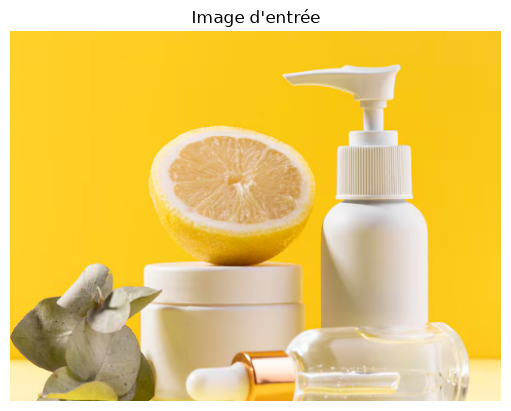

In [30]:
# Chargement robuste en RGB float32
img = io.imread(img_path)
img = util.img_as_float32(img)

if img.ndim == 2:  # grayscale -> RGB
    img = np.stack([img, img, img], axis=-1)
elif (
    img.ndim == 3 and img.shape[-1] == 4
):  # RGBA -> RGB (alpha composité sur fond blanc)
    img = color.rgba2rgb(img).astype(np.float32)

H, W, _ = img.shape
pixels = img.reshape(-1, 3)  # (N,3) en RGB

# Échantillonnage pour accélérer le clustering
rng = np.random.default_rng(42)
n_sub = min(20000, pixels.shape[0])
idx = rng.choice(pixels.shape[0], size=n_sub, replace=False)
X_sub = pixels[idx]

print("Image:", (H, W), "| pixels:", pixels.shape[0], "| échantillon:", X_sub.shape[0])

plt.imshow(img)
plt.axis("off")
plt.title("Image d'entrée")
plt.show()

In [31]:
X_sub

array([[0.9960785 , 0.80392164, 0.13333334],
       [0.6       , 0.54901963, 0.40784317],
       [0.81568635, 0.7843138 , 0.7254902 ],
       ...,
       [1.        , 0.8117648 , 0.14901961],
       [0.7607844 , 0.65882355, 0.3647059 ],
       [0.96470594, 0.77647066, 0.09803922]],
      shape=(20000, 3), dtype=float32)

In [32]:
import pandas as pd

data = pd.DataFrame(X_sub, columns=["Rouge", "Vert", "Bleu"])
data

,Rouge,Vert,Bleu
0,0.996078,0.803922,0.133333
1,0.600000,0.549020,0.407843
2,0.815686,0.784314,0.725490
3,0.992157,0.803922,0.133333
4,0.996078,0.811765,0.149020
...,...,...,...
19995,0.996078,0.811765,0.149020
19996,0.909804,0.866667,0.827451
19997,1.000000,0.811765,0.149020
19998,0.760784,0.658824,0.364706


In [33]:
import plotly.express as px

fig = px.scatter_3d(data, x="Rouge", y="Vert", z="Bleu")

fig.update_traces(marker_size=3)
fig.show()

In [34]:
from sklearn.cluster import MeanShift

mean_shift = MeanShift().fit(data)
cluster_centers = mean_shift.cluster_centers_
labels = mean_shift.labels_

In [35]:
fig = px.scatter_3d(data, x="Rouge", y="Vert", z="Bleu", color=labels)

fig.update_traces(marker_size=3)
fig.show()

On voit que sur la photo on à globalement trois couleur différentes. Par conséquent trouver trois cluster est plausible. On voit trois cluster, 0-> beaucoup de rouge puis de vert mais peu de bleu = jaune
1 -> Les trois couleur = blanc puis 2 -> les trois valeurs sont les plus faible = gris s'approchant du noir qui peut être les feuilles à gauche de l'image.

In [36]:
pd.DataFrame(labels).value_counts()

0
0    11098
1     7136
2     1766
Name: count, dtype: int64

Avec ces effectifs, on voit que les résultats du mean shift est plausible. Maintenant il faut donner la valeur de chaque point à sont centroids puis recréer l'image.

In [40]:
pixels_centroid = cluster_centers[labels]

df_centroid = pd.DataFrame(pixels_centroid, columns=["R", "G", "B"])
df_centroid

,R,G,B
0,0.984586,0.795218,0.115473
1,0.679322,0.471912,0.108072
2,0.899334,0.844197,0.764759
3,0.984586,0.795218,0.115473
4,0.984586,0.795218,0.115473
...,...,...,...
19995,0.984586,0.795218,0.115473
19996,0.899334,0.844197,0.764759
19997,0.984586,0.795218,0.115473
19998,0.679322,0.471912,0.108072


In [42]:
labels_all = mean_shift.predict(pixels)
labels_all

/home/florian/Projet_mean_shift/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but MeanShift was fitted with feature names
  warnings.warn(


array([0, 0, 0, ..., 1, 1, 1], shape=(191016,))

In [58]:
labels_corriges = labels_all.copy()

labels_corriges[labels_all == 1] = 2
labels_corriges[labels_all == 2] = 1

In [59]:
centroid_all = pixels_centroid[labels_corriges]
centroid_all

array([[0.9845865 , 0.7952184 , 0.11547337],
       [0.9845865 , 0.7952184 , 0.11547337],
       [0.9845865 , 0.7952184 , 0.11547337],
       ...,
       [0.89933354, 0.8441966 , 0.7647594 ],
       [0.89933354, 0.8441966 , 0.7647594 ],
       [0.89933354, 0.8441966 , 0.7647594 ]],
      shape=(191016, 3), dtype=float32)

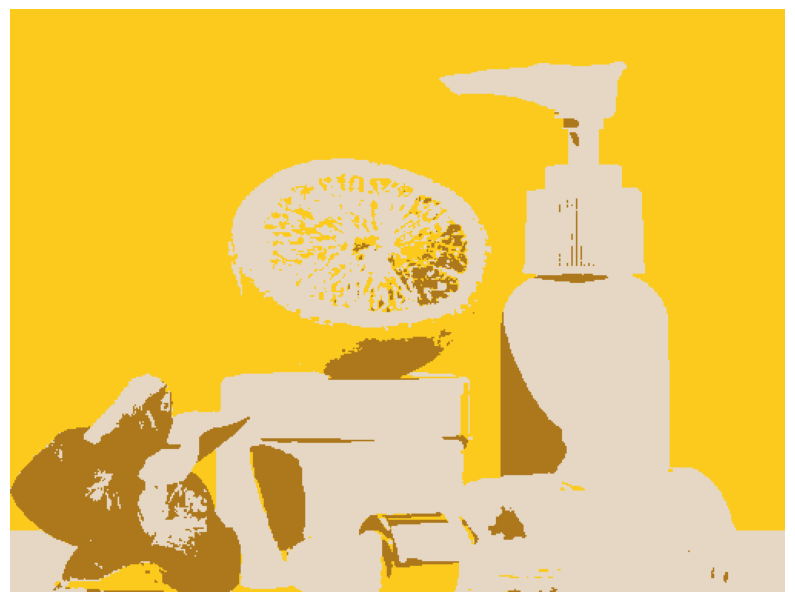

In [60]:
image = centroid_all.reshape(H, W, 3)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

On obtient une version cartoon de l'image de départ.